In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install flask pyngrok tensorflow pillow

In [ ]:
pip install fpdf opencv-python-headless

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=0d77eabcff342f1915f5699da88ca24cc0abecf7fb181bd3f03b517eaf151b19
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer
import tensorflow as tf

class Cast(Layer):
    def call(self, inputs):
        return tf.cast(inputs, tf.float16)

# Load your model
model = load_model("/content/drive/MyDrive/lungcancer/saved_models/vgg16_model.h5", custom_objects={"Cast": Cast})

# Print all layer names
for layer in model.layers:
    if 'conv' in layer.name:
        print(layer.name)

In [ ]:
import os
import io
import threading
import numpy as np
import tensorflow as tf
import cv2
import base64
import sqlite3
import traceback
import glob
from flask import Flask, request, jsonify, send_file
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.layers import Layer
from PIL import Image
from pyngrok import ngrok
from werkzeug.utils import secure_filename
from fpdf import FPDF
from datetime import datetime

# ==========================================
# 1. PATHS
# ==========================================
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

DB_PATH  = os.path.join(BASE_DIR, "oncoscan_records.db")
TEMP_DIR = os.path.join(BASE_DIR, "temp_files")
os.makedirs(TEMP_DIR, exist_ok=True)

# FIX: thread lock — model.predict() is not thread-safe under Flask's
#      multi-threaded server. All inference now goes through this lock.
PREDICT_LOCK = threading.Lock()

# FIX: max temp files to keep — prevents unlimited disk growth
MAX_TEMP_FILES = 100

def init_db():
    conn = sqlite3.connect(DB_PATH)
    c = conn.cursor()
    c.execute('''CREATE TABLE IF NOT EXISTS records (
        id          INTEGER PRIMARY KEY AUTOINCREMENT,
        filename    TEXT,
        prediction  TEXT,
        confidence  REAL,
        timestamp   TEXT,
        risk_level  TEXT,
        report_path TEXT
    )''')
    try:
        c.execute("ALTER TABLE records ADD COLUMN report_path TEXT")
    except Exception:
        pass
    conn.commit()
    conn.close()

init_db()

# ==========================================
# 3. CLASS CONFIG
# ==========================================
# FIX: MODEL_PATH now checks both .keras (new) and .h5 (legacy) automatically
SAVE_DIR    = "/content/drive/MyDrive/lungcancer/saved_models"
MODEL_KERAS = os.path.join(SAVE_DIR, "vgg16_model.keras")
MODEL_H5    = os.path.join(SAVE_DIR, "vgg16_model.h5")

# FIX: class order must match flow_from_directory alphabetical sort
# flow_from_directory sorts subdirectory names → alphabetical
# Adenocarcinoma=0, Large Cell Carcinoma=1, Normal Tissue=2, Squamous Cell Carcinoma=3
CLASS_LABELS = [
    "Adenocarcinoma",
    "Large Cell Carcinoma",
    "Normal Tissue",
    "Squamous Cell Carcinoma"
]

MEDICAL_INFO = {
    "Adenocarcinoma": {
        "desc":      "Most common lung cancer (~40% of cases). Arises from mucus-secreting glandular cells, typically in the outer lung. Often occurs in non-smokers.",
        "symptoms":  "Often asymptomatic early. Later: persistent cough, breathlessness, chest pain, unexplained weight loss.",
        "treatment": "Surgical resection (lobectomy), targeted therapy (EGFR/ALK inhibitors), chemotherapy, immunotherapy.",
        "color":     "#ef4444",
        "rgb":       (185, 28, 28),
    },
    "Large Cell Carcinoma": {
        "desc":      "Aggressive, fast-growing NSCLC with large abnormal cells. Can appear anywhere in the lung, tends to spread early.",
        "symptoms":  "Fatigue, hemoptysis (coughing blood), chest pain, shortness of breath.",
        "treatment": "Chemotherapy combinations, radiation therapy, immunotherapy (pembrolizumab).",
        "color":     "#f97316",
        "rgb":       (180, 83, 9),
    },
    "Normal Tissue": {
        "desc":      "Healthy alveolar structures with no signs of dysplasia, atypia, or malignant transformation.",
        "symptoms":  "None observed.",
        "treatment": "No treatment required. Recommend routine annual screening if high-risk.",
        "color":     "#22c55e",
        "rgb":       (21, 128, 61),
    },
    "Squamous Cell Carcinoma": {
        "desc":      "Arises from squamous epithelial cells lining the central bronchi. Strongly linked to tobacco smoking.",
        "symptoms":  "Persistent cough, wheezing, recurrent pneumonia, blood-streaked sputum.",
        "treatment": "Surgery, platinum-based chemotherapy, radiation, PD-1 immunotherapy.",
        "color":     "#a855f7",
        "rgb":       (126, 34, 206),
    }
}

# ==========================================
# 4. CUSTOM LAYER (kept for .h5 compatibility)
# ==========================================
class Cast(Layer):
    def call(self, inputs):
        return tf.cast(inputs, tf.float32)

    def get_config(self):
        return super().get_config()

# ==========================================
# 5. MODEL LOADING
# ==========================================
print("Loading model...")
model      = None
grad_model = None

def _find_last_conv(m):
    """Recursively search for the last Conv2D inside any nested sub-model."""
    for layer in reversed(m.layers):
        if isinstance(layer, tf.keras.Model):
            found = _find_last_conv(layer)
            if found:
                return found, layer          # (conv_layer, host_submodel)
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer, m
    return None, None

def build_gradcam_model(seq_model):
    """
    FIX: Build Grad-CAM model that correctly handles the nested
    Sequential → Functional VGG16 architecture produced by the new trainer.

    Strategy: trace model inputs → [conv_output, full_model_output]
    using the full sequential model's input/output so the graph is complete.
    """
    # ── Strategy 1: well-known VGG16 layer names ──────────────────────────
    target = None
    for name in ["block5_conv3", "block5_conv2", "block5_conv1",
                 "block4_conv3", "block4_conv2", "block4_conv1"]:
        try:
            target = seq_model.get_layer(name)
            print(f"Grad-CAM ▸ strategy 1 — found by name: {name}")
            break
        except ValueError:
            pass

    # ── Strategy 2: recurse into nested sub-models ────────────────────────
    if target is None:
        target, _ = _find_last_conv(seq_model)
        if target:
            print(f"Grad-CAM ▸ strategy 2 — recurse found: {target.name}")

    # ── Strategy 3: any Conv2D at top level ───────────────────────────────
    if target is None:
        for layer in reversed(seq_model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                target = layer
                print(f"Grad-CAM ▸ strategy 3 — top-level Conv2D: {layer.name}")
                break

    if target is None:
        print("Grad-CAM ▸ WARNING: no conv layer found — heatmaps disabled")
        return None

    try:
        gm = Model(
            inputs  = seq_model.inputs,
            outputs = [target.output, seq_model.output]
        )
        print(f"Grad-CAM ready  layer={target.name}  shape={target.output_shape}")
        return gm
    except Exception as e:
        print(f"Grad-CAM ▸ Model() build failed: {e}")
        traceback.print_exc()
        return None

try:
    # FIX: prefer .keras (new format), fall back to .h5
    if os.path.exists(MODEL_KERAS):
        model = load_model(MODEL_KERAS, custom_objects={"Cast": Cast})
        print(f"Loaded: {MODEL_KERAS}")
    elif os.path.exists(MODEL_H5):
        model = load_model(MODEL_H5, custom_objects={"Cast": Cast})
        print(f"Loaded: {MODEL_H5}")
    else:
        print("No saved model found — using ImageNet VGG16 (inference only)")
        model = tf.keras.applications.VGG16(weights='imagenet', include_top=True)

    # Print layer summary for debugging
    print("\nLayer list:")
    for i, layer in enumerate(model.layers):
        try:
            shape = layer.output_shape
        except Exception:
            shape = "N/A"
        print(f"  [{i:02d}] {layer.name:45s} {type(layer).__name__:25s} {str(shape)}")

    grad_model = build_gradcam_model(model)

except Exception as e:
    print(f"Model load error: {e}")
    traceback.print_exc()

# ==========================================
# 6. TEMP FILE CLEANUP
# ==========================================
def cleanup_temp_files():
    """
    FIX: keep only the most recent MAX_TEMP_FILES files in TEMP_DIR.
    Called after every prediction to prevent unbounded disk growth.
    """
    try:
        files = sorted(
            glob.glob(os.path.join(TEMP_DIR, "*")),
            key=os.path.getmtime
        )
        while len(files) > MAX_TEMP_FILES:
            oldest = files.pop(0)
            try:
                os.remove(oldest)
            except Exception:
                pass
    except Exception as e:
        print(f"Cleanup warning: {e}")

# ==========================================
# 7. GRAD-CAM COMPUTE
# ==========================================
def compute_heatmap(img_array):
    """Returns (H,W) float32 heatmap in [0,1], or None."""
    if grad_model is None:
        return None
    try:
        inp = tf.cast(img_array, tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(inp)
            conv_out, preds = grad_model(inp, training=False)
            top_idx = int(tf.argmax(preds[0]))
            loss    = preds[:, top_idx]

        grads = tape.gradient(loss, conv_out)
        if grads is None:
            print("Grad-CAM: gradient is None")
            return None

        pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
        heatmap = conv_out[0] @ pooled[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap).numpy()
        heatmap = np.maximum(heatmap, 0)
        hmax    = heatmap.max()
        if hmax > 0:
            heatmap /= hmax
        return heatmap.astype(np.float32)
    except Exception as e:
        print(f"Grad-CAM compute error: {e}")
        traceback.print_exc()
        return None

def make_overlay(orig_path, heatmap):
    """Overlay Grad-CAM heatmap on original. Returns (overlay_bgr, save_path|None)."""
    orig_cv = cv2.imread(orig_path)
    if orig_cv is None:
        return None, None
    orig_cv = cv2.resize(orig_cv, (224, 224))

    if heatmap is None:
        return orig_cv, None

    h_uint8   = np.uint8(255 * heatmap)
    h_colored = cv2.applyColorMap(h_uint8, cv2.COLORMAP_JET)
    h_colored = cv2.resize(h_colored, (224, 224))
    overlay   = cv2.addWeighted(orig_cv, 0.55, h_colored, 0.45, 0)

    save_path = os.path.join(TEMP_DIR, f"heatmap_{os.path.basename(orig_path)}.jpg")
    cv2.imwrite(save_path, overlay)
    return overlay, save_path

# ==========================================
# 8. PDF REPORT
# ==========================================

# ---------------------------------------------------------------------------
# _safe(text) — FPDF1 encodes everything as latin-1 (ISO-8859-1).
# Any Unicode codepoint > 0xFF raises UnicodeEncodeError.
# This function replaces every common offender with a safe ASCII/latin-1
# equivalent, then strips anything still outside latin-1 as a final backstop.
# Call it on EVERY string before passing it to a FPDF method.
# ---------------------------------------------------------------------------
_UNICODE_REPLACEMENTS = {
    '\u2014': '-',    # em dash      —  → -
    '\u2013': '-',    # en dash      –  → -
    '\u2012': '-',    # figure dash  ‒  → -
    '\u2010': '-',    # hyphen       ‐  → -
    '\u2011': '-',    # nb hyphen    ‑  → -
    '\u2018': "'",    # left  '      '  → '
    '\u2019': "'",    # right '      '  → '
    '\u201c': '"',    # left  "      "  → "
    '\u201d': '"',    # right "      "  → "
    '\u2026': '...',  # ellipsis     …  → ...
    '\u00d7': 'x',    # mult sign    ×  → x  (latin-1 has it at 0xD7 but
                      #   fpdf sometimes mangles it — safest to replace)
    '\u00b7': '.',    # middle dot   ·  → .
    '\u2022': '-',    # bullet       •  → -
    '\u00a0': ' ',    # nbsp             → space
    '\u2192': '->',   # right arrow  →  → ->
    '\u2190': '<-',   # left arrow   ←  → <-
}

def _safe(text: str) -> str:
    """Return a latin-1-safe version of *text* for use with FPDF1."""
    if not isinstance(text, str):
        text = str(text)
    for uni, replacement in _UNICODE_REPLACEMENTS.items():
        text = text.replace(uni, replacement)
    # Final backstop: encode to latin-1, replacing anything still unmappable
    return text.encode('latin-1', errors='replace').decode('latin-1')

BAR_COLORS = {
    "Adenocarcinoma":          (185, 28,  28),
    "Large Cell Carcinoma":    (180, 83,   9),
    "Normal Tissue":           (21, 128,  61),
    "Squamous Cell Carcinoma": (126, 34, 206),
}

class MedicalReport(FPDF):
    def header(self):
        self.set_fill_color(30, 64, 175)
        self.rect(0, 0, 210, 18, 'F')
        self.set_font('Arial', 'B', 13)
        self.set_text_color(255, 255, 255)
        self.set_y(4)
        self.cell(0, 10, _safe('OncoScan AI  |  Lung Pathology Diagnostic Report'), 0, 1, 'C')
        self.set_text_color(0, 0, 0)
        self.ln(4)

    def footer(self):
        self.set_y(-12)
        self.set_font('Arial', 'I', 7)
        self.set_text_color(150)
        self.cell(0, 6,
            _safe(f'Page {self.page_no()}  |  AI-generated report, NOT for clinical use. '
                  'Always confirm with a licensed pathologist.'), 0, 0, 'C')

    def section_title(self, text):
        self.set_fill_color(235, 240, 255)
        self.set_draw_color(180, 200, 240)
        self.set_font('Arial', 'B', 10)
        self.set_text_color(30, 64, 175)
        self.cell(0, 7, _safe(f'  {text}'), 1, 1, 'L', fill=True)
        self.set_text_color(0, 0, 0)
        self.ln(1)

    def kv_row(self, key, value, key_w=55):
        self.set_font('Arial', 'B', 9)
        self.set_text_color(80, 80, 80)
        self.cell(key_w, 6, _safe(key))
        self.set_font('Arial', '', 9)
        self.set_text_color(0, 0, 0)
        self.multi_cell(0, 6, _safe(str(value)))

def _draw_bar(pdf, label, pct, bar_rgb, is_top, x=15, bar_w=130):
    y = pdf.get_y()
    pdf.set_font('Arial', 'B' if is_top else '', 9)
    pdf.set_text_color(0)
    pdf.set_xy(x, y)
    pdf.cell(55, 6, _safe(label[:26]))
    pdf.set_fill_color(215, 215, 215)
    pdf.rect(x + 57, y + 1.5, bar_w, 4, 'F')
    r, g, b = bar_rgb
    pdf.set_fill_color(r, g, b)
    filled = max(bar_w * (pct / 100), 0.5 if pct > 0 else 0)
    pdf.rect(x + 57, y + 1.5, filled, 4, 'F')
    pdf.set_font('Arial', 'B' if is_top else '', 9)
    pdf.set_text_color(40, 40, 40)
    pdf.set_xy(x + 57 + bar_w + 3, y)
    pdf.cell(20, 6, f'{pct:.1f}%', ln=True)

def generate_report(filename, pred_label, conf_str, all_confs,
                    info, orig_path, heatmap_path, risk,
                    report_id=None, val_metrics=None):
    """
    val_metrics: optional dict with keys accuracy, macro_f1, macro_auc
                 (populated from training evaluation if available)
    """
    try:
        pdf = MedicalReport()
        pdf.set_auto_page_break(auto=True, margin=15)
        pdf.add_page()

        # ── CASE INFORMATION ─────────────────────────
        pdf.section_title("CASE INFORMATION")
        pdf.kv_row("File Name:",     filename)
        pdf.kv_row("Report ID:",     f"#{report_id}" if report_id else "N/A")
        pdf.kv_row("Analysis Date:", datetime.now().strftime("%Y-%m-%d  %H:%M:%S"))
        pdf.kv_row("AI Model:",      "VGG-16 (Fine-Tuned, Lung Histology - Block4+5 Unfrozen)")
        pdf.kv_row("Input Size:",    "224 x 224 px (resized for inference)")
        pdf.ln(3)

        # ── PRIMARY DIAGNOSIS ────────────────────────
        pdf.section_title("PRIMARY DIAGNOSIS")
        r, g, b = info.get("rgb", (30, 64, 175))
        pdf.set_font('Arial', 'B', 18)
        pdf.set_text_color(r, g, b)
        pdf.cell(0, 10, _safe(pred_label), ln=True)
        pdf.set_text_color(0)
        risk_rgb = {"High": (185, 28, 28), "Medium": (180, 83, 9), "Low": (21, 128, 61)}
        rr, rg, rb = risk_rgb.get(risk, (80, 80, 80))
        pdf.set_font('Arial', 'B', 10)
        pdf.set_text_color(rr, rg, rb)
        pdf.cell(0, 7, _safe(f"Risk Level: {risk}   |   Confidence: {conf_str}%"), ln=True)
        pdf.set_text_color(0)
        pdf.ln(2)

        # ── ALL-CLASS PROBABILITY BARS ───────────────
        pdf.section_title("PREDICTION PROBABILITIES  (all classes)")
        sorted_confs = sorted(all_confs.items(), key=lambda x: x[1], reverse=True)
        for lbl, pct in sorted_confs:
            _draw_bar(pdf, lbl, pct, BAR_COLORS.get(lbl, (80, 80, 80)),
                      is_top=(lbl == pred_label))
        pdf.ln(3)

        # ── SPECIMEN IMAGES ──────────────────────────
        pdf.section_title("SPECIMEN IMAGES")
        y_img = pdf.get_y() + 2
        pdf.set_font('Arial', 'B', 8)
        pdf.set_text_color(80, 80, 80)
        pdf.set_xy(15,  y_img); pdf.cell(85, 5, "Original Slide", 0, 0, 'C')
        pdf.set_xy(110, y_img); pdf.cell(85, 5,
            "Grad-CAM Localization" if heatmap_path else "Grad-CAM (unavailable)",
            0, 0, 'C')
        pdf.set_text_color(0)
        y_img += 6

        if orig_path and os.path.exists(orig_path):
            pdf.image(orig_path, x=15, y=y_img, w=85)
        else:
            pdf.set_xy(15, y_img)
            pdf.set_font('Arial', 'I', 8)
            pdf.cell(85, 85, "[image unavailable]", border=1, align='C')

        if heatmap_path and os.path.exists(heatmap_path):
            pdf.image(heatmap_path, x=110, y=y_img, w=85)
        else:
            pdf.set_fill_color(225, 225, 225)
            pdf.rect(110, y_img, 85, 85, 'F')
            pdf.set_xy(110, y_img + 36)
            pdf.set_font('Arial', 'I', 8)
            pdf.set_text_color(120)
            pdf.cell(85, 8, "Grad-CAM not available", 0, 0, 'C')
            pdf.set_text_color(0)
        pdf.ln(92)

        # ── CLINICAL INFORMATION ─────────────────────
        pdf.section_title("CLINICAL INFORMATION")
        pdf.set_font('Arial', 'B', 9); pdf.cell(0, 6, "About this Cell Type:", ln=True)
        pdf.set_font('Arial',  '', 9); pdf.multi_cell(0, 5, _safe(info.get('desc', 'N/A')))
        pdf.ln(2)
        pdf.set_font('Arial', 'B', 9); pdf.cell(0, 6, "Common Symptoms:", ln=True)
        pdf.set_font('Arial',  '', 9); pdf.multi_cell(0, 5, _safe(info.get('symptoms', 'N/A')))
        pdf.ln(2)
        pdf.set_font('Arial', 'B', 9); pdf.cell(0, 6, "Recommended Treatment:", ln=True)
        pdf.set_font('Arial',  '', 9); pdf.multi_cell(0, 5, _safe(info.get('treatment', 'N/A')))
        pdf.ln(4)

        # ── DISCLAIMER ───────────────────────────────
        pdf.set_fill_color(255, 251, 235)
        pdf.set_draw_color(252, 211, 77)
        pdf.set_font('Arial', 'B', 8)
        pdf.set_text_color(146, 64, 14)
        pdf.multi_cell(0, 5,
            _safe("WARNING: This report is generated by an AI model for research and educational "
                  "purposes only. It must NOT be used as a substitute for professional medical "
                  "advice, diagnosis, or treatment. Always consult a licensed pathologist or "
                  "oncologist before making any clinical decisions."),
            border=1, fill=True)
        pdf.set_text_color(0)

        safe  = filename.replace(" ", "_").replace("/", "_").replace("\\", "_")
        ts    = datetime.now().strftime("%Y%m%d_%H%M%S")
        out   = os.path.join(TEMP_DIR, f"Report_{safe}_{ts}.pdf")
        pdf.output(out)
        print(f"PDF saved: {out}")
        return out

    except Exception as e:
        print(f"PDF generation error: {e}")
        traceback.print_exc()
        return None

# ==========================================
# 9. FLASK APP
# ==========================================
app = Flask(__name__)

@app.route("/")
def home():
    return HTML_TEMPLATE

@app.route("/history")
def get_history():
    try:
        conn = sqlite3.connect(DB_PATH)
        c    = conn.cursor()
        c.execute("""SELECT id, filename, prediction, confidence,
                            timestamp, risk_level, report_path
                     FROM records ORDER BY id DESC LIMIT 50""")
        rows = c.fetchall()
        conn.close()
        return jsonify([{
            "id":         r[0],
            "filename":   r[1],
            "prediction": r[2],
            "confidence": r[3],
            "timestamp":  r[4],
            "risk":       r[5],
            "report_url": (f"/download/{os.path.basename(r[6])}"
                           if r[6] and os.path.exists(r[6]) else None)
        } for r in rows])
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route("/clear_history", methods=["POST"])
def clear_history():
    try:
        conn = sqlite3.connect(DB_PATH)
        conn.execute("DELETE FROM records")
        conn.commit(); conn.close()
        return jsonify({"success": True})
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route("/delete_record/<int:rid>", methods=["POST"])
def delete_record(rid):
    try:
        conn = sqlite3.connect(DB_PATH)
        conn.execute("DELETE FROM records WHERE id=?", (rid,))
        conn.commit(); conn.close()
        return jsonify({"success": True})
    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route("/predict", methods=["POST"])
def predict():
    if model is None:
        return jsonify({"error": "Model not loaded. Check server logs."}), 503

    if "file" not in request.files:
        return jsonify({"error": "No file uploaded."}), 400

    file = request.files["file"]
    if not file.filename:
        return jsonify({"error": "Empty filename."}), 400

    allowed = {'png', 'jpg', 'jpeg', 'tiff', 'bmp'}
    ext = file.filename.rsplit('.', 1)[-1].lower()
    if ext not in allowed:
        return jsonify({"error": f"File type '.{ext}' not allowed."}), 400

    filename  = secure_filename(file.filename)
    orig_path = os.path.join(TEMP_DIR, f"orig_{filename}")
    file.save(orig_path)

    try:
        # ── INFERENCE (thread-safe) ─────────────────
        img       = Image.open(orig_path).convert("RGB").resize((224, 224))
        img_array = img_to_array(img) / 255.0
        batch     = np.expand_dims(img_array, axis=0).astype(np.float32)

        # FIX: lock wraps both predict() and Grad-CAM to prevent race conditions
        with PREDICT_LOCK:
            preds       = model.predict(batch, verbose=0)
            raw_heatmap = compute_heatmap(batch)

        print(f"Raw predictions: {preds[0]}")

        if preds.shape[1] != len(CLASS_LABELS):
            return jsonify({
                "error": f"Model outputs {preds.shape[1]} classes but "
                         f"{len(CLASS_LABELS)} labels are defined. "
                         f"Check CLASS_LABELS order matches training."
            }), 500

        pred_idx   = int(np.argmax(preds[0]))
        pred_label = CLASS_LABELS[pred_idx]
        confidence = float(np.max(preds[0]) * 100)
        info       = MEDICAL_INFO.get(pred_label, {})
        all_confs  = {CLASS_LABELS[i]: round(float(preds[0][i]) * 100, 1)
                      for i in range(len(CLASS_LABELS))}

        # FIX: risk logic — Normal is always Low; cancer uses confidence threshold
        if "Normal" in pred_label:
            risk = "Low"
        elif confidence >= 85:
            risk = "High"
        else:
            risk = "Medium"

        # ── HEATMAP OVERLAY ─────────────────────────
        heatmap_path = None
        heatmap_b64  = None
        overlay_img, heatmap_path = make_overlay(orig_path, raw_heatmap)
        if heatmap_path and os.path.exists(heatmap_path):
            _, buf      = cv2.imencode('.jpg', overlay_img)
            heatmap_b64 = base64.b64encode(buf).decode('utf-8')

        # ── DB INSERT ───────────────────────────────
        conn   = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()
        cursor.execute(
            """INSERT INTO records
               (filename, prediction, confidence, timestamp, risk_level, report_path)
               VALUES (?,?,?,?,?,?)""",
            (filename, pred_label, f"{confidence:.1f}",
             datetime.now().strftime("%Y-%m-%d %H:%M"), risk, None)
        )
        record_id = cursor.lastrowid
        conn.commit()
        conn.close()

        # ── PDF ─────────────────────────────────────
        report_file = generate_report(
            filename, pred_label, f"{confidence:.1f}",
            all_confs, info, orig_path, heatmap_path, risk,
            report_id=record_id
        )

        if report_file:
            conn = sqlite3.connect(DB_PATH)
            conn.execute("UPDATE records SET report_path=? WHERE id=?",
                         (report_file, record_id))
            conn.commit()
            conn.close()

        report_url = (f"/download/{os.path.basename(report_file)}"
                      if report_file else None)

        # ── ENCODE ORIGINAL FOR UI ──────────────────
        with open(orig_path, "rb") as f:
            orig_b64 = "data:image/jpeg;base64," + base64.b64encode(f.read()).decode()

        # FIX: cleanup old temp files after every prediction
        cleanup_temp_files()

        return jsonify({
            "prediction":     pred_label,
            "confidence":     f"{confidence:.1f}",
            "risk":           risk,
            "all_confs":      all_confs,
            "color":          info.get("color", "#6b7280"),
            "desc":           info.get("desc",  ""),
            "symptoms":       info.get("symptoms", ""),
            "treatment":      info.get("treatment", ""),
            "original_image": orig_b64,
            "heatmap":        heatmap_b64,
            "report_url":     report_url,
            "record_id":      record_id
        })

    except Exception as e:
        traceback.print_exc()
        return jsonify({"error": str(e)}), 500

@app.route("/download/<path:fname>")
def download(fname):
    # FIX: prevent directory traversal — strip any path separators from fname
    fname = os.path.basename(fname)
    fpath = os.path.join(TEMP_DIR, fname)
    if not os.path.exists(fpath):
        return jsonify({"error": f"File '{fname}' not found"}), 404
    return send_file(fpath, as_attachment=True)

# ==========================================
# 10. HTML TEMPLATE
# ==========================================
HTML_TEMPLATE = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>OncoScan AI | Lung Pathology Analyzer</title>
<link href="https://fonts.googleapis.com/css2?family=Source+Serif+4:ital,wght@0,300;0,400;0,600;0,700;1,400&family=JetBrains+Mono:wght@300;400;500&display=swap" rel="stylesheet">
<style>
  *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
  :root {
    --bg:#f4f6f9; --card:#fff; --border:#e2e8f0; --border2:#cbd5e1;
    --text:#1e293b; --muted:#64748b; --faint:#94a3b8;
    --blue:#1d4ed8; --blue-lt:#eff6ff; --blue-md:#bfdbfe;
    --green:#15803d; --green-lt:#f0fdf4;
    --red:#b91c1c; --red-lt:#fef2f2;
    --amber:#b45309; --amber-lt:#fffbeb;
    --purple:#7e22ce; --purple-lt:#faf5ff;
    --shadow:0 1px 3px rgba(0,0,0,.08),0 1px 2px rgba(0,0,0,.04);
  }
  body { font-family:'Source Serif 4',Georgia,serif; background:var(--bg); color:var(--text); min-height:100vh; display:flex; }
  .sidebar { width:230px; flex-shrink:0; background:#fff; border-right:1px solid var(--border); display:flex; flex-direction:column; position:fixed; top:0; left:0; bottom:0; z-index:100; }
  .brand { padding:22px 20px 18px; border-bottom:1px solid var(--border); }
  .brand-name { font-size:18px; font-weight:700; color:var(--blue); }
  .brand-sub  { font-family:'JetBrains Mono',monospace; font-size:10px; color:var(--faint); margin-top:2px; }
  .nav { padding:14px 12px; display:flex; flex-direction:column; gap:2px; }
  .nav-btn { display:flex; align-items:center; gap:10px; padding:10px 12px; border-radius:8px; border:none; background:none; cursor:pointer; font-family:'Source Serif 4',serif; font-size:14px; color:var(--muted); text-align:left; width:100%; transition:background .15s,color .15s; }
  .nav-btn:hover  { background:var(--bg); color:var(--text); }
  .nav-btn.active { background:var(--blue-lt); color:var(--blue); font-weight:600; }
  .nav-btn svg { width:16px; height:16px; flex-shrink:0; }
  .sidebar-footer { margin-top:auto; padding:16px; border-top:1px solid var(--border); font-family:'JetBrains Mono',monospace; font-size:9px; color:var(--faint); line-height:1.6; }
  .main { margin-left:230px; flex:1; display:flex; flex-direction:column; min-height:100vh; }
  .topbar { background:#fff; border-bottom:1px solid var(--border); padding:14px 28px; display:flex; align-items:center; justify-content:space-between; position:sticky; top:0; z-index:50; }
  .topbar-title { font-size:16px; font-weight:600; }
  .topbar-meta  { font-family:'JetBrains Mono',monospace; font-size:11px; color:var(--faint); display:flex; align-items:center; gap:12px; }
  .status-badge { display:flex; align-items:center; gap:5px; padding:3px 8px; border-radius:20px; background:var(--green-lt); color:var(--green); font-size:10px; font-weight:500; }
  .status-dot   { width:5px; height:5px; border-radius:50%; background:var(--green); animation:blink 2s infinite; }
  @keyframes blink{0%,100%{opacity:1}50%{opacity:.4}}
  .content { flex:1; padding:28px; max-width:1100px; width:100%; margin:0 auto; }
  .tab-panel { display:none; }
  .tab-panel.active { display:block; animation:fadeUp .25s ease; }
  @keyframes fadeUp{from{opacity:0;transform:translateY(10px)}to{opacity:1;transform:translateY(0)}}
  .card { background:var(--card); border:1px solid var(--border); border-radius:12px; box-shadow:var(--shadow); padding:24px; margin-bottom:20px; }
  .card-title { font-size:13px; font-weight:600; color:var(--muted); text-transform:uppercase; letter-spacing:.8px; margin-bottom:16px; display:flex; align-items:center; gap:8px; }
  .card-title svg { width:14px; height:14px; }
  .upload-zone { border:2px dashed var(--border2); border-radius:12px; padding:48px 24px; text-align:center; cursor:pointer; transition:border-color .2s,background .2s; position:relative; }
  .upload-zone:hover,.upload-zone.drag-over { border-color:var(--blue); background:var(--blue-lt); }
  .upload-zone input { position:absolute; inset:0; opacity:0; cursor:pointer; width:100%; height:100%; }
  .upload-icon { width:52px; height:52px; background:var(--blue-lt); border-radius:50%; display:flex; align-items:center; justify-content:center; margin:0 auto 14px; border:1px solid var(--blue-md); }
  .upload-icon svg { width:22px; height:22px; stroke:var(--blue); }
  .upload-title { font-size:16px; font-weight:600; margin-bottom:4px; }
  .upload-sub   { font-size:13px; color:var(--muted); }
  .upload-hint  { font-size:11px; color:var(--faint); margin-top:8px; font-family:'JetBrains Mono',monospace; }
  .loader-wrap { display:none; flex-direction:column; align-items:center; padding:56px 24px; gap:14px; }
  .loader-wrap.show { display:flex; }
  .spinner { width:40px; height:40px; border:3px solid var(--border); border-top-color:var(--blue); border-radius:50%; animation:spin .8s linear infinite; }
  @keyframes spin{to{transform:rotate(360deg)}}
  .loader-text { font-size:14px; color:var(--muted); }
  .loader-sub  { font-family:'JetBrains Mono',monospace; font-size:11px; color:var(--faint); }
  .results-wrap { display:none; }
  .results-wrap.show { display:block; }
  .result-header { display:flex; align-items:flex-start; justify-content:space-between; flex-wrap:wrap; gap:12px; margin-bottom:16px; }
  .result-diagnosis { font-size:26px; font-weight:700; line-height:1.2; }
  .result-sub { font-size:13px; color:var(--muted); margin-top:3px; }
  .risk-badge  { padding:6px 14px; border-radius:6px; font-family:'JetBrains Mono',monospace; font-size:12px; font-weight:500; }
  .risk-high   { background:var(--red-lt);    color:var(--red);    border:1px solid #fecaca; }
  .risk-medium { background:var(--amber-lt);  color:var(--amber);  border:1px solid #fde68a; }
  .risk-low    { background:var(--green-lt);  color:var(--green);  border:1px solid #bbf7d0; }
  .conf-bar-label { display:flex; justify-content:space-between; font-size:12px; color:var(--muted); margin-bottom:6px; }
  .conf-track { height:6px; background:var(--border); border-radius:3px; overflow:hidden; margin-bottom:4px; }
  .conf-fill  { height:100%; border-radius:3px; transition:width .9s cubic-bezier(.4,0,.2,1); width:0; }
  .images-grid { display:grid; grid-template-columns:1fr 1fr; gap:16px; margin-bottom:20px; }
  .img-panel { background:var(--card); border:1px solid var(--border); border-radius:10px; overflow:hidden; box-shadow:var(--shadow); }
  .img-panel-header { padding:10px 14px; border-bottom:1px solid var(--border); font-size:11px; font-weight:600; color:var(--muted); text-transform:uppercase; letter-spacing:.6px; display:flex; align-items:center; gap:6px; }
  .img-panel img { width:100%; display:block; max-height:240px; object-fit:contain; background:#f8fafc; }
  .breakdown-list { display:flex; flex-direction:column; gap:10px; }
  .breakdown-row  { display:grid; grid-template-columns:185px 1fr 54px; gap:10px; align-items:center; }
  .breakdown-label{ font-size:13px; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; }
  .breakdown-label.active-label { font-weight:700; }
  .breakdown-track{ height:5px; background:var(--border); border-radius:3px; overflow:hidden; }
  .breakdown-fill { height:100%; border-radius:3px; transition:width 1s cubic-bezier(.4,0,.2,1); width:0; }
  .breakdown-pct  { font-family:'JetBrains Mono',monospace; font-size:11px; color:var(--muted); text-align:right; }
  .info-grid { display:grid; grid-template-columns:1fr 1fr; gap:16px; margin-bottom:16px; }
  .info-block-title { font-size:11px; font-weight:600; color:var(--muted); text-transform:uppercase; letter-spacing:.7px; margin-bottom:6px; display:flex; align-items:center; gap:5px; }
  .info-block-text  { font-size:13px; line-height:1.6; }
  .disclaimer { background:#fffbeb; border:1px solid #fde68a; border-radius:8px; padding:10px 14px; font-size:12px; color:#92400e; display:flex; gap:8px; align-items:flex-start; margin-bottom:16px; }
  .disclaimer svg { width:14px; height:14px; flex-shrink:0; margin-top:1px; }
  .btn { display:inline-flex; align-items:center; gap:6px; padding:9px 18px; border-radius:8px; border:none; font-family:'Source Serif 4',serif; font-size:13px; cursor:pointer; text-decoration:none; transition:opacity .15s,transform .1s; font-weight:500; }
  .btn:hover  { opacity:.88; transform:translateY(-1px); }
  .btn:active { transform:translateY(0); }
  .btn svg { width:14px; height:14px; }
  .btn-primary { background:var(--blue); color:#fff; }
  .btn-outline  { background:#fff; color:var(--text); border:1px solid var(--border2); }
  .btn-danger   { background:var(--red-lt); color:var(--red); border:1px solid #fecaca; }
  .actions-row  { display:flex; align-items:center; gap:10px; flex-wrap:wrap; margin-top:14px; }
  .table-wrap { overflow-x:auto; border-radius:10px; border:1px solid var(--border); box-shadow:var(--shadow); }
  table { width:100%; border-collapse:collapse; background:var(--card); font-size:13px; }
  thead th { padding:11px 16px; background:var(--bg); border-bottom:1px solid var(--border); text-align:left; font-size:11px; font-weight:600; color:var(--muted); text-transform:uppercase; letter-spacing:.6px; font-family:'JetBrains Mono',monospace; }
  tbody td { padding:12px 16px; border-bottom:1px solid var(--border); vertical-align:middle; }
  tbody tr:last-child td { border-bottom:none; }
  tbody tr:hover { background:var(--bg); }
  .pred-pill    { display:inline-block; padding:2px 8px; border-radius:4px; font-size:11px; font-weight:500; }
  .pred-normal  { background:var(--green-lt);  color:var(--green);  border:1px solid #bbf7d0; }
  .pred-cancer  { background:var(--red-lt);    color:var(--red);    border:1px solid #fecaca; }
  .pred-large   { background:var(--amber-lt);  color:var(--amber);  border:1px solid #fde68a; }
  .pred-squamous{ background:var(--purple-lt); color:var(--purple); border:1px solid #e9d5ff; }
  .empty-state  { text-align:center; padding:40px; color:var(--faint); font-size:13px; }
  .section-head { display:flex; align-items:center; justify-content:space-between; margin-bottom:18px; }
  .section-title{ font-size:20px; font-weight:600; }
  .section-sub  { font-size:13px; color:var(--muted); margin-top:2px; }
  .icon-btn { background:none; border:none; cursor:pointer; padding:4px 6px; border-radius:4px; color:var(--faint); transition:color .15s; }
  .icon-btn:hover { color:var(--red); }
  /* model info banner */
  .model-banner { background:var(--blue-lt); border:1px solid var(--blue-md); border-radius:8px; padding:8px 14px; font-family:'JetBrains Mono',monospace; font-size:10px; color:var(--blue); margin-bottom:16px; display:flex; align-items:center; gap:8px; }
</style>
</head>
<body>

<nav class="sidebar">
  <div class="brand">
    <div class="brand-name">OncoScan AI</div>
    <div class="brand-sub">LUNG PATHOLOGY v3.0</div>
  </div>
  <div class="nav">
    <button class="nav-btn active" id="nav-scan" onclick="showTab('scan')">
      <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><circle cx="11" cy="11" r="8"/><path d="m21 21-4.35-4.35"/></svg>
      New Analysis
    </button>
    <button class="nav-btn" id="nav-records" onclick="showTab('records')">
      <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M14 2H6a2 2 0 00-2 2v16a2 2 0 002 2h12a2 2 0 002-2V8z"/><polyline points="14 2 14 8 20 8"/><line x1="16" y1="13" x2="8" y2="13"/><line x1="16" y1="17" x2="8" y2="17"/></svg>
      Patient Records
    </button>
  </div>
  <div class="sidebar-footer">WARNING: RESEARCH USE ONLY<br>Not for clinical diagnosis.<br>Consult a licensed physician.</div>
</nav>

<div class="main">
  <div class="topbar">
    <span class="topbar-title" id="topbar-title">New Specimen Analysis</span>
    <div class="topbar-meta">
      <div class="status-badge"><div class="status-dot"></div>Model Online</div>
      <span>VGG-16 · Block4+5 Fine-Tuned</span>
    </div>
  </div>

  <div class="content">
    <div class="tab-panel active" id="tab-scan">

      <div class="card" id="upload-card">
        <div class="card-title">
          <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><polyline points="16 16 12 12 8 16"/><line x1="12" y1="12" x2="12" y2="21"/><path d="M20.39 18.39A5 5 0 0018 9h-1.26A8 8 0 103 16.3"/></svg>
          Upload Histology Specimen
        </div>
        <div class="upload-zone" id="uploadZone">
          <input type="file" id="fileInput" accept=".jpg,.jpeg,.png,.tiff,.bmp">
          <div class="upload-icon">
            <svg viewBox="0 0 24 24" fill="none" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"><path d="M21 15v4a2 2 0 01-2 2H5a2 2 0 01-2-2v-4M17 8l-5-5-5 5M12 3v12"/></svg>
          </div>
          <div class="upload-title">Drop image here, or click to browse</div>
          <div class="upload-sub">Histological lung tissue slide</div>
          <div class="upload-hint">Accepts: JPG · PNG · TIFF · BMP</div>
        </div>
      </div>

      <div class="card loader-wrap" id="loaderWrap">
        <div class="spinner"></div>
        <div class="loader-text">Analyzing specimen...</div>
        <div class="loader-sub">Running VGG-16 inference + Grad-CAM + generating PDF</div>
      </div>

      <div class="results-wrap" id="resultsWrap">

        <div class="card">
          <div class="result-header">
            <div>
              <div class="card-title" style="margin-bottom:6px;">
                <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M22 11.08V12a10 10 0 11-5.93-9.14"/><polyline points="22 4 12 14.01 9 11.01"/></svg>
                Diagnostic Result
              </div>
              <div class="result-diagnosis" id="resDiagnosis">—</div>
              <div class="result-sub"      id="resSubtext">—</div>
            </div>
            <div id="riskBadge" class="risk-badge">—</div>
          </div>
          <div>
            <div class="conf-bar-label"><span>Model Confidence</span><strong id="resConfText">—</strong></div>
            <div class="conf-track"><div class="conf-fill" id="mainBar" style="background:#1d4ed8;"></div></div>
          </div>
        </div>

        <div class="images-grid">
          <div class="img-panel">
            <div class="img-panel-header">
              <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round" width="12" height="12"><rect x="3" y="3" width="18" height="18" rx="2"/><circle cx="8.5" cy="8.5" r="1.5"/><polyline points="21 15 16 10 5 21"/></svg>
              Original Slide
            </div>
            <img id="imgOrig" src="" alt="Original">
          </div>
          <div class="img-panel">
            <div class="img-panel-header">
              <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round" width="12" height="12"><circle cx="12" cy="12" r="10"/><line x1="12" y1="8" x2="12" y2="12"/><line x1="12" y1="16" x2="12.01" y2="16"/></svg>
              <span id="heatmapLabel">Grad-CAM Localization</span>
            </div>
            <img id="imgHeat" src="" alt="Heatmap">
          </div>
        </div>

        <div class="card">
          <div class="card-title">
            <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><line x1="18" y1="20" x2="18" y2="10"/><line x1="12" y1="20" x2="12" y2="4"/><line x1="6" y1="20" x2="6" y2="14"/></svg>
            All Class Probabilities
          </div>
          <div class="breakdown-list" id="breakdownList"></div>
        </div>

        <div class="card">
          <div class="card-title">
            <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M2 3h6a4 4 0 014 4v14a3 3 0 00-3-3H2z"/><path d="M22 3h-6a4 4 0 00-4 4v14a3 3 0 013-3h7z"/></svg>
            Clinical Information
          </div>
          <div style="margin-bottom:16px;">
            <div class="info-block-title">About this Cell Type</div>
            <div class="info-block-text" id="txtDesc">—</div>
          </div>
          <div class="info-grid">
            <div>
              <div class="info-block-title">Common Symptoms</div>
              <div class="info-block-text" id="txtSymptoms">—</div>
            </div>
            <div>
              <div class="info-block-title">Recommended Treatment</div>
              <div class="info-block-text" id="txtTreatment">—</div>
            </div>
          </div>
          <div class="disclaimer">
            <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M10.29 3.86L1.82 18a2 2 0 001.71 3h16.94a2 2 0 001.71-3L13.71 3.86a2 2 0 00-3.42 0z"/><line x1="12" y1="9" x2="12" y2="13"/><line x1="12" y1="17" x2="12.01" y2="17"/></svg>
            For research purposes only. Always confirm with a licensed pathologist before any clinical decision.
          </div>
          <div class="actions-row">
            <button class="btn btn-outline" onclick="resetUI()">
              <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><polyline points="1 4 1 10 7 10"/><path d="M3.51 15a9 9 0 102.13-9.36L1 10"/></svg>
              Analyze New Specimen
            </button>
            <a class="btn btn-primary" id="btnReport" href="#" target="_blank">
              <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><path d="M21 15v4a2 2 0 01-2 2H5a2 2 0 01-2-2v-4M7 10l5 5 5-5M12 15V3"/></svg>
              Download PDF Report
            </a>
          </div>
        </div>

      </div>
    </div>

    <div class="tab-panel" id="tab-records">
      <div class="section-head">
        <div>
          <div class="section-title">Patient Records</div>
          <div class="section-sub">Full analysis history with downloadable PDF reports</div>
        </div>
        <div style="display:flex;gap:8px;">
          <button class="btn btn-outline" onclick="loadHistory()">
            <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><polyline points="23 4 23 10 17 10"/><polyline points="1 20 1 14 7 14"/><path d="M3.51 9a9 9 0 0114.85-3.36L23 10M1 14l4.64 4.36A9 9 0 0020.49 15"/></svg>
            Refresh
          </button>
          <button class="btn btn-danger" onclick="clearAll()">
            <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><polyline points="3 6 5 6 21 6"/><path d="M19 6l-1 14a2 2 0 01-2 2H8a2 2 0 01-2-2L5 6"/></svg>
            Clear All
          </button>
        </div>
      </div>
      <div class="table-wrap">
        <table>
          <thead>
            <tr>
              <th>ID</th><th>Filename</th><th>Diagnosis</th>
              <th>Confidence</th><th>Risk</th><th>Date</th>
              <th>PDF Report</th><th></th>
            </tr>
          </thead>
          <tbody id="historyBody">
            <tr><td colspan="8" class="empty-state">Loading records...</td></tr>
          </tbody>
        </table>
      </div>
    </div>

  </div>
</div>

<script>
  const COLORS = {
    "Adenocarcinoma":          { bar:"#ef4444", pill:"pred-cancer"   },
    "Large Cell Carcinoma":    { bar:"#f97316", pill:"pred-large"    },
    "Normal Tissue":           { bar:"#22c55e", pill:"pred-normal"   },
    "Squamous Cell Carcinoma": { bar:"#a855f7", pill:"pred-squamous" }
  };

  function showTab(name) {
    document.querySelectorAll('.tab-panel').forEach(p => p.classList.remove('active'));
    document.querySelectorAll('.nav-btn').forEach(b => b.classList.remove('active'));
    document.getElementById('tab-' + name).classList.add('active');
    document.getElementById('nav-' + name).classList.add('active');
    document.getElementById('topbar-title').textContent =
      name === 'scan' ? 'New Specimen Analysis' : 'Patient Records';
    if (name === 'records') loadHistory();
  }

  const fileInput   = document.getElementById('fileInput');
  const uploadZone  = document.getElementById('uploadZone');
  const uploadCard  = document.getElementById('upload-card');
  const loaderWrap  = document.getElementById('loaderWrap');
  const resultsWrap = document.getElementById('resultsWrap');

  uploadZone.addEventListener('dragover',  e => { e.preventDefault(); uploadZone.classList.add('drag-over'); });
  uploadZone.addEventListener('dragleave', () => uploadZone.classList.remove('drag-over'));
  uploadZone.addEventListener('drop', e => {
    e.preventDefault(); uploadZone.classList.remove('drag-over');
    if (e.dataTransfer.files[0]) handleFile(e.dataTransfer.files[0]);
  });
  fileInput.addEventListener('change', e => { if (e.target.files[0]) handleFile(e.target.files[0]); });

  async function handleFile(file) {
    uploadCard.style.display = 'none';
    loaderWrap.classList.add('show');
    resultsWrap.classList.remove('show');
    const fd = new FormData();
    fd.append('file', file);
    try {
      const res  = await fetch('/predict', { method:'POST', body:fd });
      const data = await res.json();
      if (data.error) throw new Error(data.error);
      loaderWrap.classList.remove('show');
      renderResults(data);
      resultsWrap.classList.add('show');
    } catch(err) {
      loaderWrap.classList.remove('show');
      uploadCard.style.display = '';
      alert('Error: ' + err.message);
    }
  }

  function renderResults(data) {
    document.getElementById('resDiagnosis').textContent = data.prediction;
    document.getElementById('resSubtext').textContent =
      data.confidence + '% confidence  |  Record #' + (data.record_id || '—');
    document.getElementById('resConfText').textContent = data.confidence + '%';

    const badge = document.getElementById('riskBadge');
    const rMap  = { High:['risk-high','High Risk'], Medium:['risk-medium','Medium Risk'], Low:['risk-low','Low Risk'] };
    const [cls, lbl] = rMap[data.risk] || ['risk-low','Low'];
    badge.className   = 'risk-badge ' + cls;
    badge.textContent = lbl;

    const col = COLORS[data.prediction]?.bar || '#1d4ed8';
    document.getElementById('mainBar').style.background = col;
    setTimeout(() => { document.getElementById('mainBar').style.width = data.confidence + '%'; }, 80);

    document.getElementById('imgOrig').src = data.original_image;
    if (data.heatmap) {
      document.getElementById('imgHeat').src = 'data:image/jpeg;base64,' + data.heatmap;
      document.getElementById('heatmapLabel').textContent = 'Grad-CAM Localization';
    } else {
      document.getElementById('imgHeat').src = data.original_image;
      document.getElementById('heatmapLabel').textContent = 'Grad-CAM (unavailable — showing original)';
    }

    const list = document.getElementById('breakdownList');
    list.innerHTML = '';
    if (data.all_confs) {
      Object.entries(data.all_confs).sort((a,b) => b[1]-a[1]).forEach(([lbl, pct]) => {
        const isTop  = lbl === data.prediction;
        const barCol = COLORS[lbl]?.bar || '#94a3b8';
        const row    = document.createElement('div');
        row.className = 'breakdown-row';
        row.innerHTML = `
          <div class="breakdown-label ${isTop ? 'active-label' : ''}">${lbl}</div>
          <div class="breakdown-track">
            <div class="breakdown-fill" data-w="${pct}"
                 style="background:${barCol};opacity:${isTop?1:0.35};"></div>
          </div>
          <div class="breakdown-pct">${pct}%</div>`;
        list.appendChild(row);
      });
      setTimeout(() => {
        list.querySelectorAll('.breakdown-fill').forEach(el => {
          el.style.width = el.dataset.w + '%';
        });
      }, 150);
    }

    document.getElementById('txtDesc').textContent      = data.desc      || '—';
    document.getElementById('txtSymptoms').textContent  = data.symptoms  || '—';
    document.getElementById('txtTreatment').textContent = data.treatment || '—';

    const btn = document.getElementById('btnReport');
    if (data.report_url) {
      btn.href = data.report_url;
      btn.style.opacity = '1';
      btn.style.pointerEvents = '';
    } else {
      btn.href = '#';
      btn.style.opacity = '0.4';
      btn.style.pointerEvents = 'none';
    }
  }

  function resetUI() {
    fileInput.value = '';
    uploadCard.style.display = '';
    loaderWrap.classList.remove('show');
    resultsWrap.classList.remove('show');
  }

  async function loadHistory() {
    const tbody = document.getElementById('historyBody');
    tbody.innerHTML = '<tr><td colspan="8" class="empty-state">Loading...</td></tr>';
    try {
      const rows = await (await fetch('/history')).json();
      if (!rows.length) {
        tbody.innerHTML = '<tr><td colspan="8" class="empty-state">No records yet.</td></tr>';
        return;
      }
      tbody.innerHTML = rows.map(r => {
        const riskCls = r.risk==='High' ? 'risk-high' : r.risk==='Medium' ? 'risk-medium' : 'risk-low';
        const pillCls = COLORS[r.prediction]?.pill || 'pred-normal';
        const dlBtn   = r.report_url
          ? `<a href="${r.report_url}" target="_blank" class="btn btn-outline"
                style="padding:4px 10px;font-size:11px;gap:4px;">
               <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2"
                    stroke-linecap="round" stroke-linejoin="round" width="12" height="12">
                 <path d="M21 15v4a2 2 0 01-2 2H5a2 2 0 01-2-2v-4M7 10l5 5 5-5M12 15V3"/>
               </svg>PDF</a>`
          : `<span style="font-size:11px;color:var(--faint)">—</span>`;
        return `<tr>
          <td style="font-family:'JetBrains Mono',monospace;font-size:11px;color:var(--faint)">#${r.id}</td>
          <td style="font-weight:500;max-width:140px;overflow:hidden;text-overflow:ellipsis;white-space:nowrap;"
              title="${r.filename}">${r.filename}</td>
          <td><span class="pred-pill ${pillCls}">${r.prediction}</span></td>
          <td style="font-family:'JetBrains Mono',monospace;font-size:12px;">${r.confidence}%</td>
          <td><span class="risk-badge ${riskCls}" style="font-size:10px;padding:3px 8px;">${r.risk}</span></td>
          <td style="font-size:12px;color:var(--muted);">${r.timestamp}</td>
          <td>${dlBtn}</td>
          <td>
            <button class="icon-btn" onclick="deleteRecord(${r.id})" title="Delete record">
              <svg viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2"
                   stroke-linecap="round" stroke-linejoin="round" width="14" height="14">
                <polyline points="3 6 5 6 21 6"/>
                <path d="M19 6l-1 14a2 2 0 01-2 2H8a2 2 0 01-2-2L5 6"/>
              </svg>
            </button>
          </td>
        </tr>`;
      }).join('');
    } catch(e) {
      tbody.innerHTML = `<tr><td colspan="8" class="empty-state" style="color:var(--red)">
        Failed to load: ${e.message}</td></tr>`;
    }
  }

  async function deleteRecord(id) {
    if (!confirm('Delete this record?')) return;
    await fetch(`/delete_record/${id}`, { method:'POST' });
    loadHistory();
  }

  async function clearAll() {
    if (!confirm('Delete ALL records permanently?')) return;
    await fetch('/clear_history', { method:'POST' });
    loadHistory();
  }
</script>
</body>
</html>"""

# ==========================================
# 11. LAUNCH
# ==========================================
# FIX: read ngrok token from environment variable — never hardcode secrets
NGROK_TOKEN = os.environ.get("NGROK_AUTHTOKEN", "")
if not NGROK_TOKEN:
    # Fallback for Colab: set via  %env NGROK_AUTHTOKEN=your_token
    # or: import os; os.environ["NGROK_AUTHTOKEN"] = "your_token"
    raise RuntimeError(
        "NGROK_AUTHTOKEN environment variable not set.\n"
        "Run:  import os; os.environ['NGROK_AUTHTOKEN'] = ''\n"
        "before starting the app."
    )

ngrok.kill()
ngrok.set_auth_token(NGROK_TOKEN)
public_url = ngrok.connect(5000).public_url
print(f"\n✓ OncoScan AI is live: {public_url}\n")

# FIX: threaded=False — single-threaded with PREDICT_LOCK is safer for TF inference
app.run(port=5000, threaded=False)

Loading model...
Loaded: /content/drive/MyDrive/lungcancer/saved_models/vgg16_model.keras

Layer list:
  [00] vgg16                                         Functional                (None, 512)
  [01] batch_normalization                           BatchNormalization        N/A
  [02] dense                                         Dense                     N/A
  [03] dropout                                       Dropout                   N/A
  [04] batch_normalization_1                         BatchNormalization        N/A
  [05] dense_1                                       Dense                     N/A
  [06] dropout_1                                     Dropout                   N/A
  [07] dense_2                                       Dense                     N/A
Model load error: 'tuple' object has no attribute 'name'


Traceback (most recent call last):
  File "/tmp/ipython-input-339865832.py", line 211, in <cell line: 0>
    grad_model = build_gradcam_model(model)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-339865832.py", line 164, in build_gradcam_model
    print(f"Grad-CAM ▸ strategy 2 — recurse found: {target.name}")
                                                    ^^^^^^^^^^^
AttributeError: 'tuple' object has no attribute 'name'



✓ OncoScan AI is live: https://f82a-34-26-207-212.ngrok-free.app

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [25/Feb/2026 08:41:56] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/Feb/2026 08:42:01] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [25/Feb/2026 08:42:36] "POST /predict HTTP/1.1" 200 -


Raw predictions: [3.6626803e-03 9.9589229e-01 8.7375502e-06 4.3621185e-04]
PDF saved: /content/temp_files/Report_3.jpg_20260225_084236.pdf


INFO:werkzeug:127.0.0.1 - - [25/Feb/2026 08:42:51] "GET /history HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/Feb/2026 08:43:01] "POST /delete_record/1 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/Feb/2026 08:43:02] "GET /history HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/Feb/2026 08:43:06] "GET /history HTTP/1.1" 200 -


Found 315 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


10/10 ━━━━━━━━━━━━━━━━━━━━ 183s 19s/step


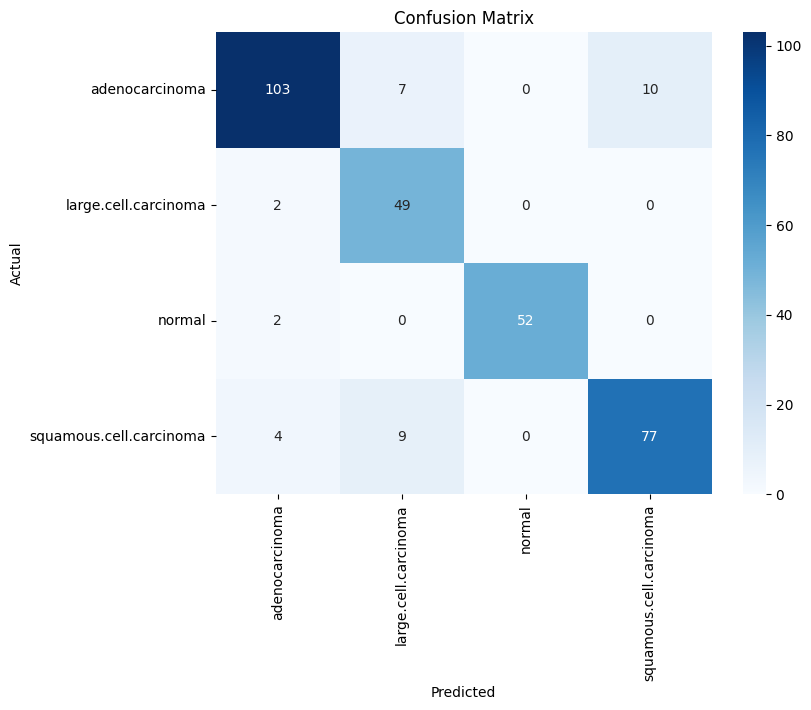

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma       0.93      0.86      0.89       120
   large.cell.carcinoma       0.75      0.96      0.84        51
                 normal       1.00      0.96      0.98        54
squamous.cell.carcinoma       0.89      0.86      0.87        90

               accuracy                           0.89       315
              macro avg       0.89      0.91      0.90       315
           weighted avg       0.90      0.89      0.89       315



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
model_path = "/content/drive/MyDrive/lungcancer/saved_models/vgg16_model.h5"
model = load_model(model_path, custom_objects={"Cast": Cast})
test_dir = '/content/drive/MyDrive/LungCancer/Data/test'
img_height, img_width = 224, 224
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # important for consistent labels
)

# Get class labels
class_labels = list(test_generator.class_indices.keys())
y_pred_probs = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))



1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


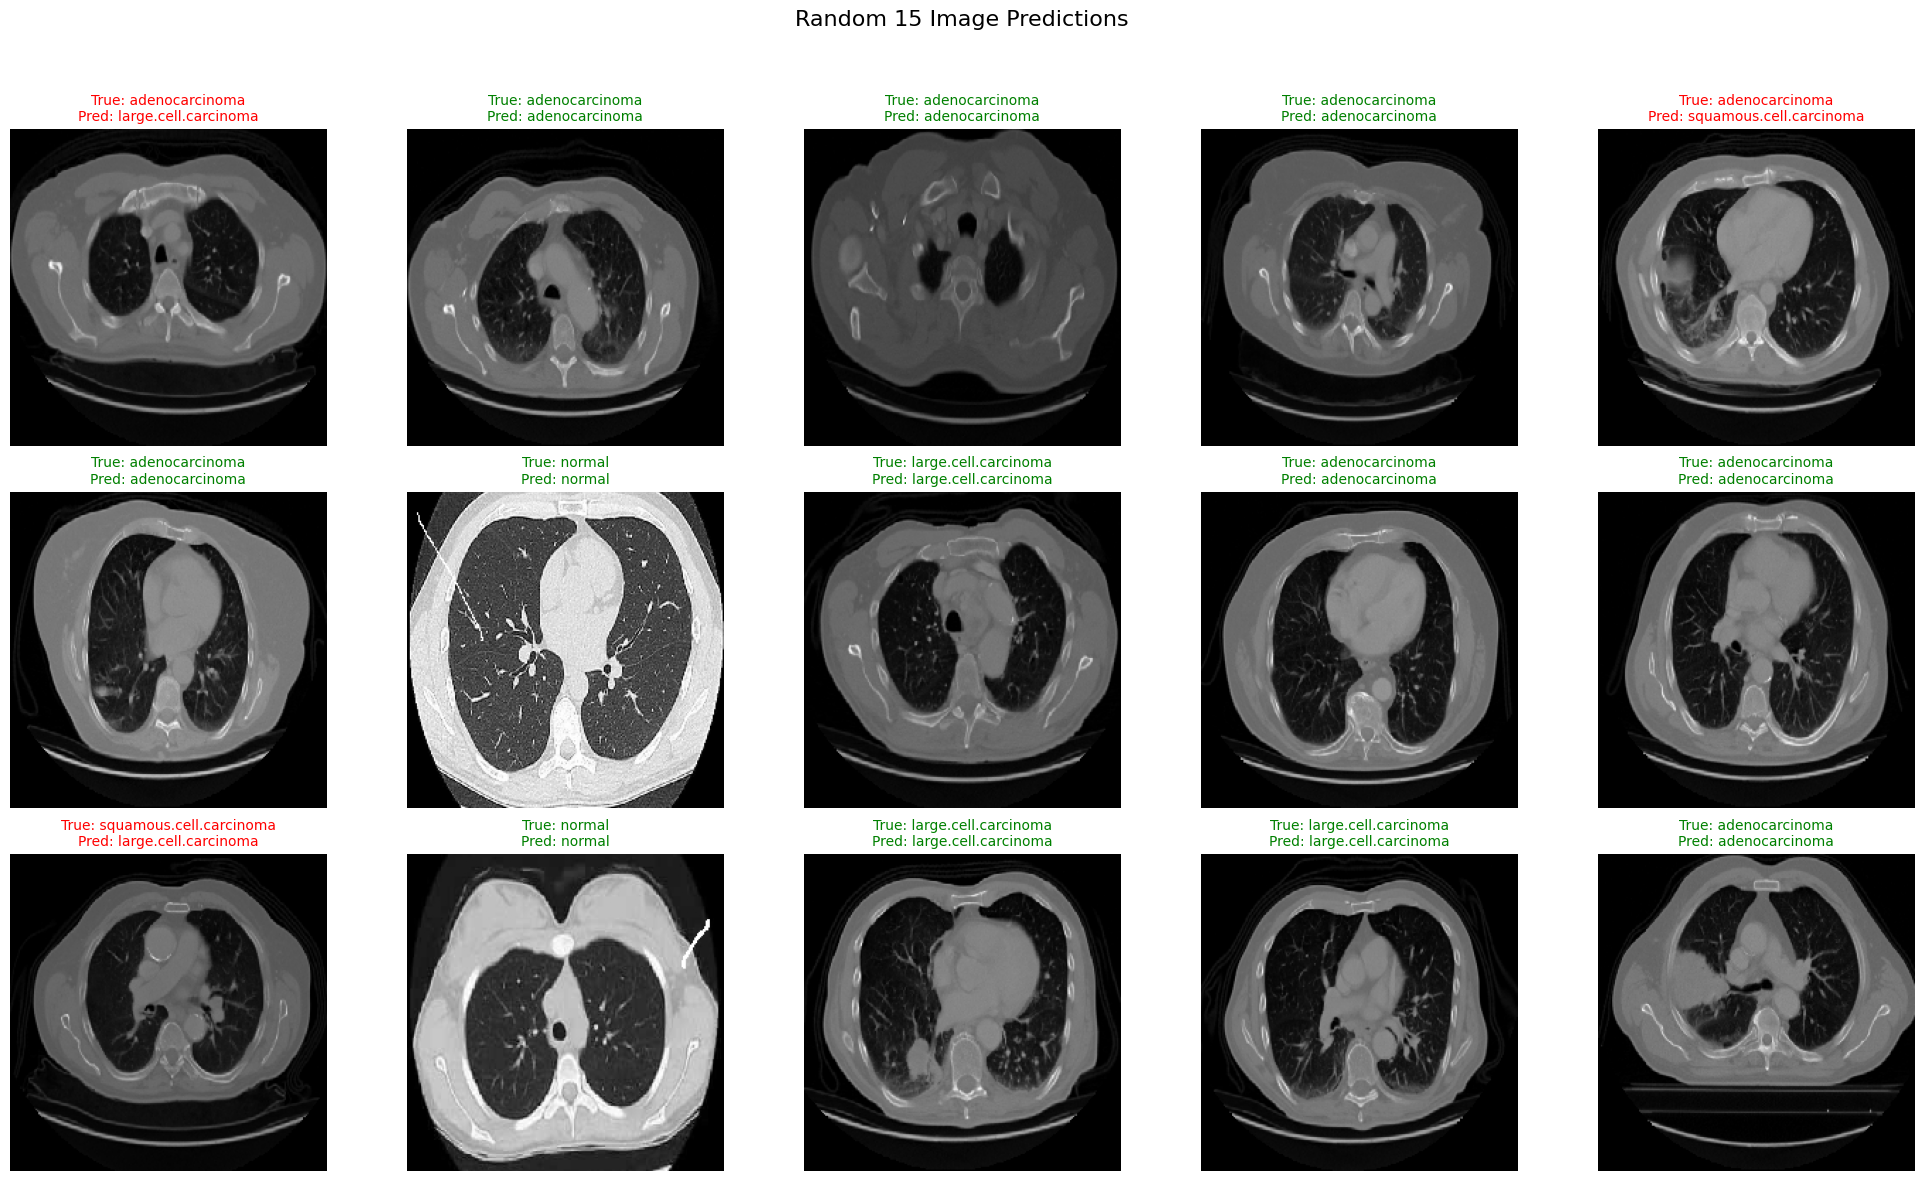

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# Load model
model_path = "/content/drive/MyDrive/lungcancer/saved_models/vgg16_model.h5"
model = load_model(model_path, custom_objects={"Cast": Cast})

# Test directory
test_dir = '/content/drive/MyDrive/LungCancer/Data/test'
img_height, img_width = 224, 224

# Class labels
class_labels = sorted(os.listdir(test_dir))  # assuming class folders are named accordingly

# Gather all image paths with corresponding labels
image_paths = []
for label in class_labels:
    class_path = os.path.join(test_dir, label)
    for img_file in os.listdir(class_path):
        if img_file.lower().endswith(('jpg', 'jpeg', 'png')):
            image_paths.append((os.path.join(class_path, img_file), label))

# Randomly select 15 images
sampled_images = random.sample(image_paths, 15)

# Prepare data for prediction
images = []
true_labels = []
for img_path, label in sampled_images:
    img = load_img(img_path, target_size=(img_height, img_width))
    img_array = img_to_array(img) / 255.0
    images.append(img_array)
    true_labels.append(label)

images = np.array(images)

# Make predictions
pred_probs = model.predict(images)
pred_indices = np.argmax(pred_probs, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]


plt.figure(figsize=(20, 12))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(f"True: {true_labels[i]}\nPred: {pred_labels[i]}", fontsize=10, color='green' if true_labels[i] == pred_labels[i] else 'red')
plt.suptitle("Random 15 Image Predictions", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


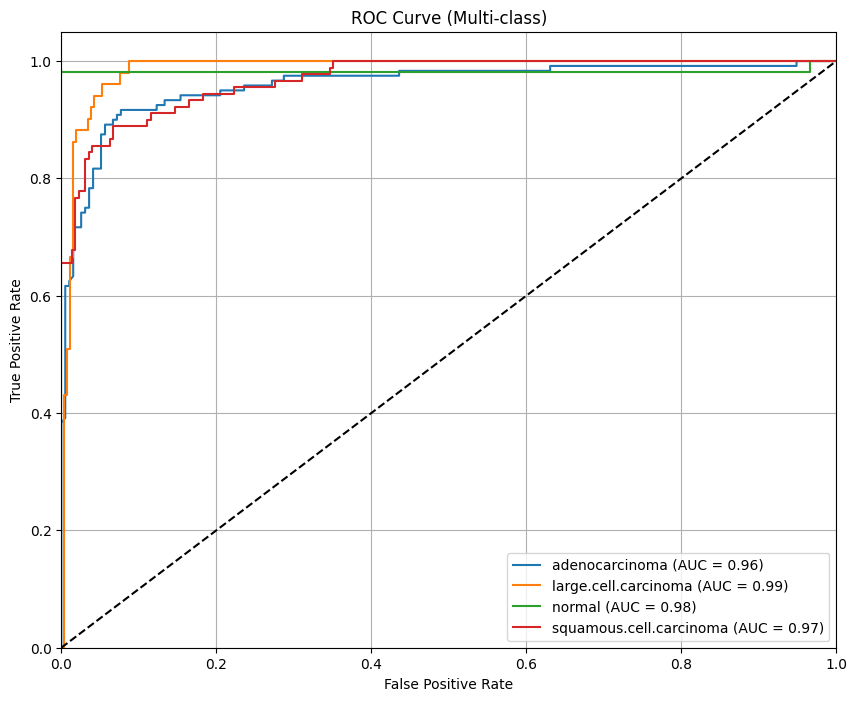

In [ ]:
# Binarize the true labels
y_true_bin = label_binarize(y_true, classes=range(len(class_labels)))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-class)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:

n = 7
mid = n / 2 + 1  # Fixed: Use // for integer division

for i in range(1, n + 1):
    for j in range(1, n + 1):
        if (i == mid and j == mid or
           (i == 1 and j >mid) or
           (j == 1 and i < mid) or
           (i == n and j < mid) or
           (j == n and i > mid)):
            print("*", end=" ")
        else:
            print(" ", end=" ")
    print()

*       * * * 
*             
*             
*             
            * 
            * 
* * * *     * 
